# Prepare the data

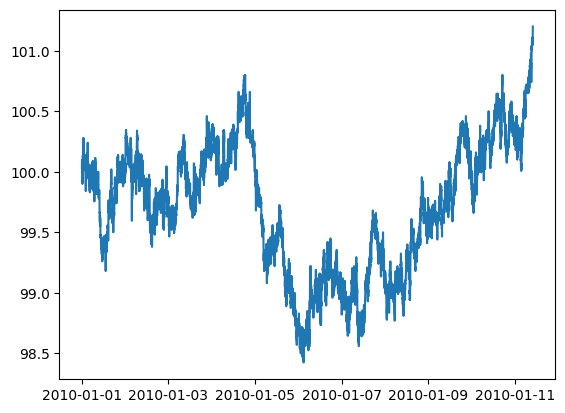

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from participants import simulate, prepare_data

# Run the simulation and prepare the data
n = 150_000
timestamped_data = simulate(decisions=n, seed=50)
ohlcv = prepare_data(timestamped_data, verbose=False)
plt.plot(ohlcv["close"])
plt.show()

# Reset the index for processing later
ohlcv = ohlcv.reset_index()

In [10]:
# Copy the dataframe ohlcv for further modifications
X = ohlcv.copy()

# Create the target y and shift it by -1 minute.
# The target is the next minutes return direction
X['y'] = (ohlcv['close'].pct_change(1).shift(-1) > 0).astype(int)

# Remove the created nan
X = X.dropna()


# Create more features
for i in ["open", "high", "low", "close", "volume", "n_trades"]:
    for t in [1, 5, 10, 20]:
        # Create percentage change features
        X[f"{i}_pct_{t}"] = X[i].pct_change(t)
        if t > 1:
            # Create rolling mean and standard deviation features
            X[f"{i}_mean_{t}"] = X[i].rolling(t).mean()
            X[f"{i}_std_{t}"] = X[i].rolling(t).std()

# Create lagged return features
for k in [1, 2]:
    X[f"close_pct_lag_{k}"] = X['close'].pct_change(1).shift(k)

# Create a feature from the best bid and best ask orderbook data
X["snapshot_imbalance"] = X["best_bid_qty"] / (X["best_bid_qty"] +X ["best_ask_qty"])


# Replace inf values with nan
X = X.replace([np.inf, -np.inf], np.nan)
# Fill nans with last available value
X = X.ffill()
# Remove leading nans
X = X.dropna()


# Separate the features and target
# Assumption: The features will all be available at the time of prediction.

# use X[['y']] to avoid conversion to Series
y = X[['y']] 
# Also remove timestamp because model cannot handle datetime input
X = X[[x for x in X.columns if x not in ['y', 'timestamp']]]
X, y

(          open     high     low    close  volume  n_trades  best_bid_qty  \
 20      99.900   99.960   99.90   99.960    56.0         3          11.0   
 21      99.960   99.960   99.96   99.960     0.0         0           0.0   
 22      99.960   99.990   99.96   99.980     0.0         0          19.0   
 23      99.980   99.980   99.98   99.980     0.0         0          19.0   
 24      99.980   99.990   99.98   99.990    64.0         5          16.0   
 ...        ...      ...     ...      ...     ...       ...           ...   
 14995  101.080  101.085  101.08  101.085    58.0         3          19.0   
 14996  101.085  101.085  101.08  101.080    22.0         3           8.0   
 14997  101.080  101.160  101.08  101.160    17.0         3           3.0   
 14998  101.160  101.185  101.16  101.180     0.0         0           0.0   
 14999  101.180  101.200  101.17  101.200    10.4         3          17.0   
 
        best_ask_qty  open_pct_1  open_pct_5  ...  n_trades_std_5  \
 20  

# Train the models

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import xgboost as xgb

def run_model(choice: str, X: pd.DataFrame, y: pd.DataFrame):
    # Validation
    if not isinstance(choice, str):
        raise TypeError(f"choice must be a str, got {type(choice)}")
    if not isinstance(X, pd.DataFrame):
        raise TypeError(f"X must be a pd.DataFrame, got {type(X)}")
    if not isinstance(y, pd.DataFrame):
        raise TypeError(f"y must be a pd.DataFrame, got {type(y)}")
    if X.empty or y.empty:
        raise ValueError("X and y cannot be empty")


    # Initialize the Time Series cross-validator
    # Train size is expanding and 
    # Test size by default is n_samples // (n_splits + 1)
    tscv = TimeSeriesSplit(n_splits=5)

    scores = []

    # Use enumerate(..., 1) to make i start at 1
    for i, (train_index, test_index) in enumerate(tscv.split(X), 1):

        # Select the relevant indices using .iloc
        X_train = X.iloc[train_index] 
        X_test = X.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        # Scale the feature data
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Set the model
        if choice == "XGB":
            model = xgb.XGBClassifier(n_estimators=300, max_depth=3, seed=10)
        elif choice == "LR":
            # max_iter avoids warnings
            model = LogisticRegression(random_state=10, max_iter=1000)
        elif choice == "RF":
            model = RandomForestClassifier(n_estimators=300, max_depth=3, random_state=10)
        else:
            raise ValueError(f"Unknown model choice: {choice}")
        
        # Train the model
        # values.ravel() is needed to avoid a warning
        model.fit(X_train, y_train.values.ravel())

        # Create the predictions. Slice to get the predictions for 1 (True)
        predicted_probabilities = model.predict_proba(X_test)[:, 1]
        # predicted_outcome = model.predict(X_test)

        # Evaluate
        roc_auc_test = roc_auc_score(y_test, predicted_probabilities)
        scores.append(roc_auc_test)
   
    # Note: This returns the scores over all folds and the final model, which will get used for feature importance.
    return scores, model

models = {}
model_scores = {}

# Run the models and store the scores + models
for i in ["XGB", "LR", "RF"]:
    score, model = run_model(choice=i, X=X, y=y)
    model_scores[i] = score
    models[i] = model

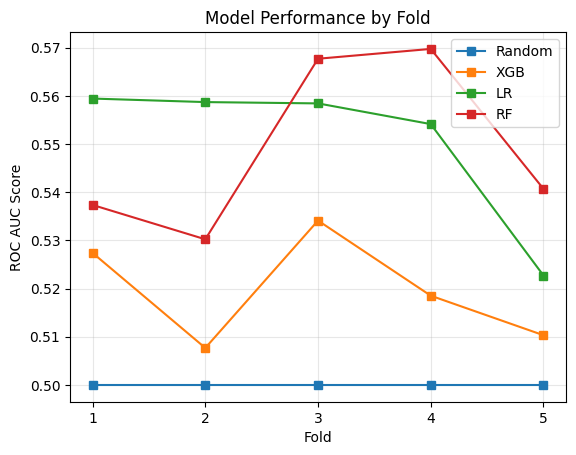

In [12]:
# Convert the dictionary to df
model_scores_df = pd.DataFrame(model_scores)

# The ROC AUC of a random classifier is 0.5. This will be the baseline
model_scores_df['Random'] = [0.5] * 5
model_scores_df['fold'] = model_scores_df.index + 1

# Plot the model scores
for model in ["Random", "XGB", "LR", "RF"]:
    plt.plot(
        model_scores_df["fold"],
        model_scores_df[model],
        marker="s", label=model
    )

plt.title("Model Performance by Fold")
plt.xlabel("Fold")
plt.ylabel("ROC AUC Score")
plt.xticks(model_scores_df["fold"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

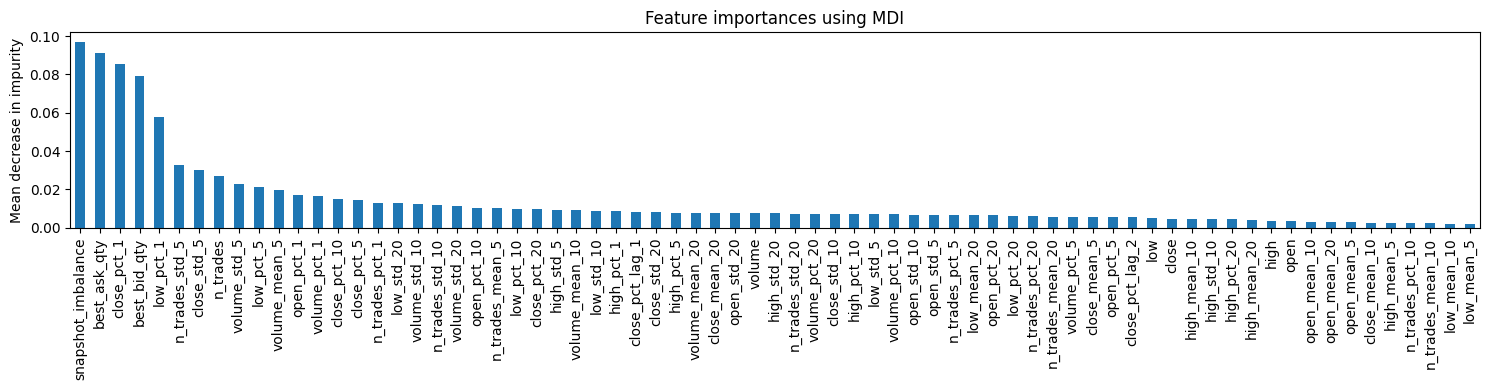

In [13]:
# Get the feature importances from the RF model
importances = pd.Series(models["RF"].feature_importances_, index=X.columns)
# Sort the values descendingly
importances = importances.sort_values(ascending=False)

# Create a plot
fig, ax = plt.subplots(figsize=(15, 4))
importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

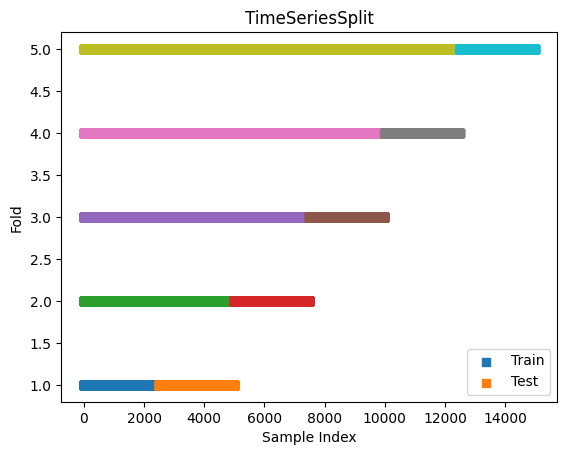

In [14]:
# Visualize the used data splits (folds)
tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    plt.scatter(train_idx, [fold] * len(train_idx), label="Train" if fold == 1 else "", marker="s")
    plt.scatter(test_idx, [fold] * len(test_idx), label="Test" if fold == 1 else "", marker="s")

plt.title("TimeSeriesSplit")
plt.xlabel("Sample Index")
plt.ylabel("Fold")
plt.legend()
plt.show()

# Data characteristics

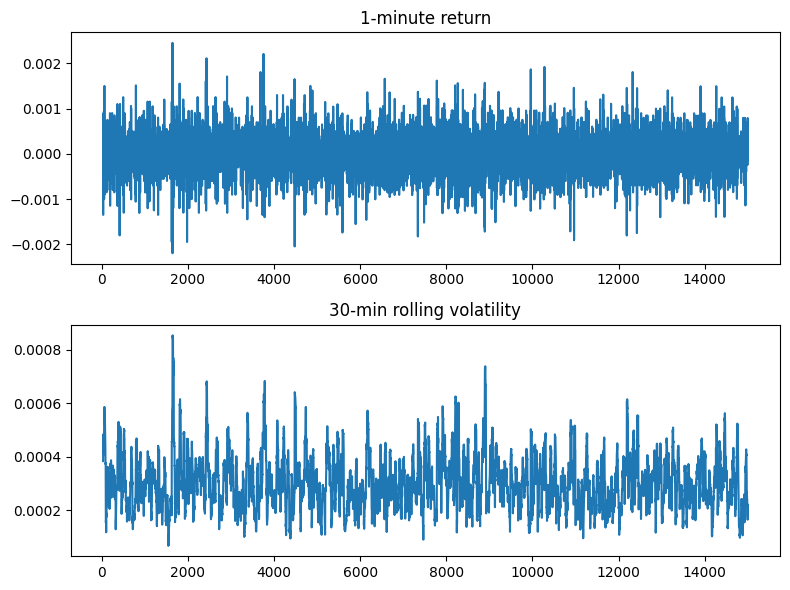

Skewness: 0.03
Kurtosis (3 = normal dist.): 4.81


In [15]:
descriptive = ohlcv.copy()
descriptive['return_1'] = descriptive['close'].pct_change(1)
descriptive['vol_30'] = descriptive['return_1'].rolling(30).std()

# Drop nans created by rolling stats
descriptive = descriptive.dropna()

fig, ax = plt.subplots(2, 1, figsize=(8,6))
ax[0].set_title("1-minute return")
ax[0].plot(descriptive['return_1'])
ax[1].set_title("30-min rolling volatility")
ax[1].plot(descriptive['vol_30'])

# Better spacing
plt.tight_layout()
plt.show()

print(f"Skewness: {descriptive['return_1'].skew():.2f}")
print(f"Kurtosis (3 = normal dist.): {descriptive['return_1'].kurtosis():.2f}")

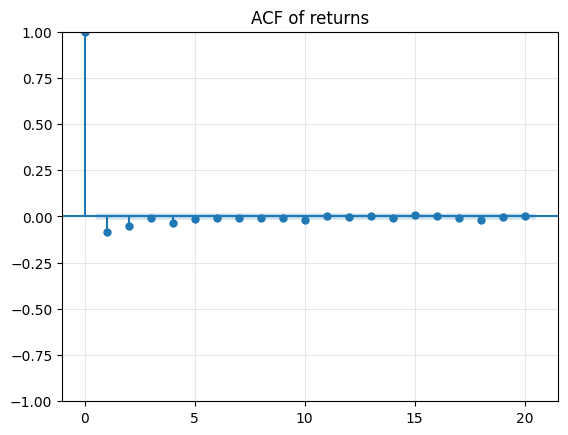

In [16]:
# Autocorrelation of returns
from statsmodels.graphics.tsaplots import plot_acf
r = descriptive['return_1'].dropna()
plot_acf(r, lags=20)
plt.grid(alpha=0.3)
plt.title("ACF of returns")
plt.show()